# SQIL and IQ-Learn on AntMaze Medium (Confounded)

In [1]:
import random
import torch
import pickle
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

from collections import defaultdict

from causal_gym import AntMazePCH
from causal_rl.algo.imitation.imitate import *
from causal_rl.algo.imitation.gail.core_net import ContinuousActor
from causal_rl.algo.imitation.gail.causal_gail import *

from causal_rl.algo.imitation.sqil.causal_sqil import *
from causal_rl.algo.imitation.sqil.core_net import SACQNetwork

from causal_rl.algo.imitation.iqlearn.causal_iqlearn import *
from causal_rl.algo.imitation.iqlearn.core_net import IQLearnQNetwork

<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.


/home/et2842/miniconda3/envs/causalenv/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
num_steps = 1000
seed = 0
lookback = 1
hidden_dims = {'O'}

random.seed(seed)
torch.manual_seed(seed)

In [4]:
expert_env = AntMazePCH(num_steps=num_steps, expert_mode=True, seed=seed)

In [5]:
env = AntMazePCH(num_steps=num_steps, seed=seed)

# Causal Graph Analysis

In [6]:
# to save time; conceptually the same
small_steps = lookback + 1
small_env = AntMazePCH(num_steps=small_steps, seed=seed)
G = parse_graph(small_env.get_graph)
X_small = {f'X{t}' for t in range(small_steps)}
Y = f'Y{small_steps}'

X = {f'X{t}' for t in range(num_steps)}
obs_prefix = env.env.observed_unobserved_vars[0]

In [7]:
Z_sets = find_sequential_pi_backdoor(G, X_small, Y, obs_prefix)

base_step = small_steps - 1
base_Z_set = Z_sets[f'X{base_step}']

for i in range(base_step + 1, num_steps):
    updated_base_Z_set = set()
    for v in base_Z_set:
        updated_base_Z_set.add(f'{v[0]}{int(v[1:]) + i - lookback}')

    Z_sets[f'X{i}'] = updated_base_Z_set

Z_sets['X1']

{'A0', 'A1', 'J0', 'J1', 'L0', 'L1', 'P0', 'P1', 'T0', 'T1', 'X0'}

In [8]:
naive_Z_sets = {}
for Xi in X:
    i = int(Xi[1:])
    cond = set()

    for j in range(i+1):
        cond.update({f'{o}{j}' for o in list(set(obs_prefix) - {'X'})})

    for j in range(i):
        cond.add(f'X{j}')
    naive_Z_sets[Xi] = cond

naive_Z_sets['X1']

{'A0', 'A1', 'J0', 'J1', 'L0', 'L1', 'P0', 'P1', 'T0', 'T1', 'W0', 'W1', 'X0'}

# Expert Trajectories

In [9]:
with open('/home/et2842/causal/expert_traj.pkl', 'rb') as f:
    records = pickle.load(f)

print(f'loaded {len(records)} trajectories')

loaded 379882 trajectories


In [10]:
dims = {
    'P': 3,
    'A': 8,
    'L': 3,
    'T': 3,
    'J': 8,
    'W': 2,
    'X': 8,
}

causal_Z_trim = trim_Z_sets(Z_sets, lookback=lookback)
naive_Z_trim  = trim_Z_sets(naive_Z_sets, lookback=lookback)

causal_encode, causal_z_dim, causal_slots = build_windowed_z_encoder(
    causal_Z_trim, dims=dims, lookback=lookback,
)
naive_encode, naive_z_dim, naive_slots = build_windowed_z_encoder(
    naive_Z_trim, dims=dims, lookback=lookback,
)

print(f'Causal z_dim: {causal_z_dim}, Naive z_dim: {naive_z_dim}')

Causal z_dim: 58, Naive z_dim: 62


# Training Hyperparameters

In [11]:
# Shared SAC hyperparameters
total_timesteps = 3_000_000
batch_size = 256
gamma = 0.99
tau = 0.005
actor_lr = 3e-4
critic_lr = 3e-4
alpha_lr = 3e-4
hidden_dim = 256
buffer_capacity = 1_000_000
expert_capacity_ratio = 0.5
start_steps = 5_000
log_every = 50
eval_episodes = 5
max_grad_norm = 1.0

# Actor architecture (match GAIL)
num_blocks_actor = 3
dropout_actor = 0.05
layernorm_actor = True

# IQ-Learn specific
num_v_samples = 10

# Environment action space
action_dim = env.env.action_space.shape[0]
action_low = float(env.env.action_space.low.min())
action_high = float(env.env.action_space.high.max())
target_entropy = -float(action_dim)

# SQIL Training

In [12]:
# --- Causal SQIL setup ---
causal_sqil_actor = ContinuousActor(
    num_inputs=causal_z_dim, num_outputs=action_dim,
    hidden_size=hidden_dim, std=0.0,
    action_low=action_low, action_high=action_high,
    num_blocks=num_blocks_actor, dropout=dropout_actor, layernorm=layernorm_actor,
).to(device)

causal_sqil_q1 = SACQNetwork(causal_z_dim, action_dim, hidden_dim).to(device)
causal_sqil_q2 = SACQNetwork(causal_z_dim, action_dim, hidden_dim).to(device)
causal_sqil_tq1 = copy.deepcopy(causal_sqil_q1)
causal_sqil_tq2 = copy.deepcopy(causal_sqil_q2)
for p in causal_sqil_tq1.parameters(): p.requires_grad = False
for p in causal_sqil_tq2.parameters(): p.requires_grad = False

causal_sqil_actor_optim = torch.optim.Adam(causal_sqil_actor.parameters(), lr=actor_lr)
causal_sqil_q1_optim = torch.optim.Adam(causal_sqil_q1.parameters(), lr=critic_lr)
causal_sqil_q2_optim = torch.optim.Adam(causal_sqil_q2.parameters(), lr=critic_lr)

# Automatic entropy tuning
causal_sqil_log_alpha = torch.zeros(1, requires_grad=True, device=device)
causal_sqil_alpha_optim = torch.optim.Adam([causal_sqil_log_alpha], lr=alpha_lr)

causal_sqil_buffer = SQILReplayBuffer(buffer_capacity, expert_capacity_ratio)
initialize_expert_buffer(records, causal_encode, causal_sqil_buffer, device)

Expert buffer: 379882 transitions from 1000 episodes


In [13]:
causal_sqil_ts = 0
causal_sqil_ep = 0
logs_causal_sqil = []

while causal_sqil_ts < total_timesteps:
    ep_data = rollout_sqil_episode(
        env, causal_sqil_actor, causal_sqil_buffer, causal_encode,
        num_steps, device, deterministic=False, seed=seed + causal_sqil_ep
    )
    causal_sqil_ts += ep_data['episode_length']
    causal_sqil_ep += 1

    if causal_sqil_ts > start_steps and len(causal_sqil_buffer.policy_buffer) >= batch_size:
        for _ in range(ep_data['episode_length']):
            sac_update(
                causal_sqil_q1, causal_sqil_q2, causal_sqil_tq1, causal_sqil_tq2,
                causal_sqil_actor, causal_sqil_log_alpha, target_entropy,
                causal_sqil_q1_optim, causal_sqil_q2_optim,
                causal_sqil_actor_optim, causal_sqil_alpha_optim,
                causal_sqil_buffer, batch_size, gamma, device, max_grad_norm,
            )
            soft_update(causal_sqil_q1, causal_sqil_tq1, tau)
            soft_update(causal_sqil_q2, causal_sqil_tq2, tau)

    if causal_sqil_ep % log_every == 0:
        eval_ret = evaluate_sqil_policy(
            env, causal_sqil_actor, causal_encode, num_steps, device, eval_episodes, seed=42
        )
        logs_causal_sqil.append({
            'episode': causal_sqil_ep, 'timesteps': causal_sqil_ts,
            'eval_return': eval_ret, 'train_return': ep_data['episode_return'],
            'alpha': causal_sqil_log_alpha.exp().item(),
        })
        print(
            f"[Causal SQIL ep {causal_sqil_ep}] "
            f"ts={causal_sqil_ts}, eval={eval_ret:.2f}, "
            f"train={ep_data['episode_return']:.2f}, "
            f"alpha={causal_sqil_log_alpha.exp().item():.4f}"
        )

[Causal SQIL ep 50] ts=50000, eval=-281.71, train=-351.71, alpha=0.0251


[Causal SQIL ep 100] ts=100000, eval=-296.63, train=-93.08, alpha=0.0182


[Causal SQIL ep 150] ts=148765, eval=-237.19, train=-100.03, alpha=0.0211


[Causal SQIL ep 200] ts=190278, eval=-78.67, train=-159.79, alpha=0.0229


[Causal SQIL ep 250] ts=233426, eval=-146.46, train=-328.92, alpha=0.0227


...

[Causal SQIL ep 3800] ts=2821628, eval=-153.28, train=-433.19, alpha=0.0262


[Causal SQIL ep 3850] ts=2866251, eval=-205.15, train=-227.38, alpha=0.0257


[Causal SQIL ep 3900] ts=2908496, eval=-115.16, train=-276.61, alpha=0.0246


[Causal SQIL ep 3950] ts=2940986, eval=-207.19, train=-212.27, alpha=0.0262


[Causal SQIL ep 4000] ts=2990986, eval=-299.21, train=-369.21, alpha=0.0264


In [14]:
# --- Naive SQIL setup ---
naive_sqil_actor = ContinuousActor(
    num_inputs=naive_z_dim, num_outputs=action_dim,
    hidden_size=hidden_dim, std=0.0,
    action_low=action_low, action_high=action_high,
    num_blocks=num_blocks_actor, dropout=dropout_actor, layernorm=layernorm_actor,
).to(device)

naive_sqil_q1 = SACQNetwork(naive_z_dim, action_dim, hidden_dim).to(device)
naive_sqil_q2 = SACQNetwork(naive_z_dim, action_dim, hidden_dim).to(device)
naive_sqil_tq1 = copy.deepcopy(naive_sqil_q1)
naive_sqil_tq2 = copy.deepcopy(naive_sqil_q2)
for p in naive_sqil_tq1.parameters(): p.requires_grad = False
for p in naive_sqil_tq2.parameters(): p.requires_grad = False

naive_sqil_actor_optim = torch.optim.Adam(naive_sqil_actor.parameters(), lr=actor_lr)
naive_sqil_q1_optim = torch.optim.Adam(naive_sqil_q1.parameters(), lr=critic_lr)
naive_sqil_q2_optim = torch.optim.Adam(naive_sqil_q2.parameters(), lr=critic_lr)

# Automatic entropy tuning
naive_sqil_log_alpha = torch.zeros(1, requires_grad=True, device=device)
naive_sqil_alpha_optim = torch.optim.Adam([naive_sqil_log_alpha], lr=alpha_lr)

naive_sqil_buffer = SQILReplayBuffer(buffer_capacity, expert_capacity_ratio)
sqil_init_expert_buffer(records, naive_encode, naive_sqil_buffer, device)

Expert buffer: 379882 transitions from 1000 episodes


In [15]:
naive_sqil_ts = 0
naive_sqil_ep = 0
logs_naive_sqil = []

while naive_sqil_ts < total_timesteps:
    ep_data = rollout_sqil_episode(
        env, naive_sqil_actor, naive_sqil_buffer, naive_encode,
        num_steps, device, deterministic=False, seed=seed + 10_000 + naive_sqil_ep
    )
    naive_sqil_ts += ep_data['episode_length']
    naive_sqil_ep += 1

    if naive_sqil_ts > start_steps and len(naive_sqil_buffer.policy_buffer) >= batch_size:
        for _ in range(ep_data['episode_length']):
            sac_update(
                naive_sqil_q1, naive_sqil_q2, naive_sqil_tq1, naive_sqil_tq2,
                naive_sqil_actor, naive_sqil_log_alpha, target_entropy,
                naive_sqil_q1_optim, naive_sqil_q2_optim,
                naive_sqil_actor_optim, naive_sqil_alpha_optim,
                naive_sqil_buffer, batch_size, gamma, device, max_grad_norm,
            )
            soft_update(naive_sqil_q1, naive_sqil_tq1, tau)
            soft_update(naive_sqil_q2, naive_sqil_tq2, tau)

    if naive_sqil_ep % log_every == 0:
        eval_ret = evaluate_sqil_policy(
            env, naive_sqil_actor, naive_encode, num_steps, device, eval_episodes, seed=42
        )
        logs_naive_sqil.append({
            'episode': naive_sqil_ep, 'timesteps': naive_sqil_ts,
            'eval_return': eval_ret, 'train_return': ep_data['episode_return'],
            'alpha': naive_sqil_log_alpha.exp().item(),
        })
        print(
            f"[Naive SQIL ep {naive_sqil_ep}] "
            f"ts={naive_sqil_ts}, eval={eval_ret:.2f}, "
            f"train={ep_data['episode_return']:.2f}, "
            f"alpha={naive_sqil_log_alpha.exp().item():.4f}"
        )

[Naive SQIL ep 50] ts=50000, eval=-369.25, train=-486.43, alpha=0.0234


[Naive SQIL ep 100] ts=100000, eval=-356.72, train=-498.68, alpha=0.0270


[Naive SQIL ep 150] ts=150000, eval=-363.87, train=-308.37, alpha=0.0360


[Naive SQIL ep 200] ts=200000, eval=-360.12, train=-431.68, alpha=0.0488


[Naive SQIL ep 250] ts=250000, eval=-365.64, train=-363.54, alpha=0.0614


...

[Naive SQIL ep 2800] ts=2800000, eval=-361.59, train=-268.17, alpha=0.0463


[Naive SQIL ep 2850] ts=2850000, eval=-361.16, train=-526.42, alpha=0.0641


[Naive SQIL ep 2900] ts=2900000, eval=-361.66, train=-345.06, alpha=0.0637


[Naive SQIL ep 2950] ts=2950000, eval=-360.64, train=-173.78, alpha=0.0535


[Naive SQIL ep 3000] ts=3000000, eval=-363.20, train=-268.66, alpha=0.0806


# IQ-Learn Training

In [16]:
# --- Causal IQ-Learn setup (twin Q-networks + auto entropy) ---
causal_iq_actor = ContinuousActor(
    num_inputs=causal_z_dim, num_outputs=action_dim,
    hidden_size=hidden_dim, std=0.0,
    action_low=action_low, action_high=action_high,
    num_blocks=num_blocks_actor, dropout=dropout_actor, layernorm=layernorm_actor,
).to(device)

causal_iq_q1 = IQLearnQNetwork(causal_z_dim, action_dim, hidden_dim).to(device)
causal_iq_q2 = IQLearnQNetwork(causal_z_dim, action_dim, hidden_dim).to(device)
causal_iq_tq1 = copy.deepcopy(causal_iq_q1)
causal_iq_tq2 = copy.deepcopy(causal_iq_q2)
for p in causal_iq_tq1.parameters(): p.requires_grad = False
for p in causal_iq_tq2.parameters(): p.requires_grad = False

causal_iq_actor_optim = torch.optim.Adam(causal_iq_actor.parameters(), lr=actor_lr)
causal_iq_q1_optim = torch.optim.Adam(causal_iq_q1.parameters(), lr=critic_lr)
causal_iq_q2_optim = torch.optim.Adam(causal_iq_q2.parameters(), lr=critic_lr)

# Automatic entropy tuning
causal_iq_log_alpha = torch.zeros(1, requires_grad=True, device=device)
causal_iq_alpha_optim = torch.optim.Adam([causal_iq_log_alpha], lr=alpha_lr)

causal_iq_buffer = IQLearnReplayBuffer(buffer_capacity, expert_capacity_ratio)
iq_init_expert_buffer(records, causal_encode, causal_iq_buffer, device)

Expert buffer: 379882 transitions from 1000 episodes


In [17]:
causal_iq_ts = 0
causal_iq_ep = 0
logs_causal_iq = []

while causal_iq_ts < total_timesteps:
    ep_data = rollout_iqlearn_episode(
        env, causal_iq_actor, causal_iq_buffer, causal_encode,
        num_steps, device, deterministic=False, seed=seed + 20_000 + causal_iq_ep
    )
    causal_iq_ts += ep_data['episode_length']
    causal_iq_ep += 1

    if causal_iq_ts > start_steps and len(causal_iq_buffer.policy_buffer) >= batch_size // 2:
        alpha_val = causal_iq_log_alpha.exp().item()
        for _ in range(ep_data['episode_length']):
            alpha_val = causal_iq_log_alpha.exp().item()
            iqlearn_update_critic(
                causal_iq_q1, causal_iq_q2, causal_iq_tq1, causal_iq_tq2,
                causal_iq_actor, alpha_val, causal_iq_buffer,
                batch_size, gamma, causal_iq_q1_optim, causal_iq_q2_optim,
                device, num_v_samples, max_grad_norm,
            )
            iqlearn_update_actor(
                causal_iq_actor, causal_iq_q1, causal_iq_q2,
                causal_iq_log_alpha, target_entropy,
                causal_iq_actor_optim, causal_iq_alpha_optim,
                causal_iq_buffer, batch_size, device, max_grad_norm,
            )
            soft_update(causal_iq_q1, causal_iq_tq1, tau)
            soft_update(causal_iq_q2, causal_iq_tq2, tau)

    if causal_iq_ep % log_every == 0:
        eval_ret = evaluate_iqlearn_policy(
            env, causal_iq_actor, causal_encode, num_steps, device, eval_episodes, seed=42
        )
        logs_causal_iq.append({
            'episode': causal_iq_ep, 'timesteps': causal_iq_ts,
            'eval_return': eval_ret, 'train_return': ep_data['episode_return'],
            'alpha': causal_iq_log_alpha.exp().item(),
        })
        print(
            f"[Causal IQ-Learn ep {causal_iq_ep}] "
            f"ts={causal_iq_ts}, eval={eval_ret:.2f}, "
            f"train={ep_data['episode_return']:.2f}, "
            f"alpha={causal_iq_log_alpha.exp().item():.4f}"
        )

[Causal IQ-Learn ep 50] ts=50000, eval=-288.20, train=-213.28, alpha=0.0462


[Causal IQ-Learn ep 100] ts=98856, eval=-268.49, train=-344.37, alpha=0.0393


[Causal IQ-Learn ep 150] ts=146537, eval=-230.36, train=-345.15, alpha=0.0445


[Causal IQ-Learn ep 200] ts=190450, eval=-249.15, train=-169.06, alpha=0.0437


[Causal IQ-Learn ep 250] ts=228255, eval=-239.63, train=-99.88, alpha=0.0495


...

[Causal IQ-Learn ep 3750] ts=2792087, eval=-289.94, train=-319.31, alpha=0.1280


[Causal IQ-Learn ep 3800] ts=2842087, eval=-274.80, train=-196.63, alpha=0.1095


[Causal IQ-Learn ep 3850] ts=2892087, eval=-308.19, train=-418.32, alpha=0.0998


[Causal IQ-Learn ep 3900] ts=2942087, eval=-290.92, train=-349.11, alpha=0.0878


[Causal IQ-Learn ep 3950] ts=2992087, eval=-303.86, train=-320.75, alpha=0.0760


In [18]:
# --- Naive IQ-Learn setup (twin Q-networks + auto entropy) ---
naive_iq_actor = ContinuousActor(
    num_inputs=naive_z_dim, num_outputs=action_dim,
    hidden_size=hidden_dim, std=0.0,
    action_low=action_low, action_high=action_high,
    num_blocks=num_blocks_actor, dropout=dropout_actor, layernorm=layernorm_actor,
).to(device)

naive_iq_q1 = IQLearnQNetwork(naive_z_dim, action_dim, hidden_dim).to(device)
naive_iq_q2 = IQLearnQNetwork(naive_z_dim, action_dim, hidden_dim).to(device)
naive_iq_tq1 = copy.deepcopy(naive_iq_q1)
naive_iq_tq2 = copy.deepcopy(naive_iq_q2)
for p in naive_iq_tq1.parameters(): p.requires_grad = False
for p in naive_iq_tq2.parameters(): p.requires_grad = False

naive_iq_actor_optim = torch.optim.Adam(naive_iq_actor.parameters(), lr=actor_lr)
naive_iq_q1_optim = torch.optim.Adam(naive_iq_q1.parameters(), lr=critic_lr)
naive_iq_q2_optim = torch.optim.Adam(naive_iq_q2.parameters(), lr=critic_lr)

# Automatic entropy tuning
naive_iq_log_alpha = torch.zeros(1, requires_grad=True, device=device)
naive_iq_alpha_optim = torch.optim.Adam([naive_iq_log_alpha], lr=alpha_lr)

naive_iq_buffer = IQLearnReplayBuffer(buffer_capacity, expert_capacity_ratio)
iq_init_expert_buffer(records, naive_encode, naive_iq_buffer, device)

Expert buffer: 379882 transitions from 1000 episodes


In [19]:
naive_iq_ts = 0
naive_iq_ep = 0
logs_naive_iq = []

while naive_iq_ts < total_timesteps:
    ep_data = rollout_iqlearn_episode(
        env, naive_iq_actor, naive_iq_buffer, naive_encode,
        num_steps, device, deterministic=False, seed=seed + 30_000 + naive_iq_ep
    )
    naive_iq_ts += ep_data['episode_length']
    naive_iq_ep += 1

    if naive_iq_ts > start_steps and len(naive_iq_buffer.policy_buffer) >= batch_size // 2:
        alpha_val = naive_iq_log_alpha.exp().item()
        for _ in range(ep_data['episode_length']):
            alpha_val = naive_iq_log_alpha.exp().item()
            iqlearn_update_critic(
                naive_iq_q1, naive_iq_q2, naive_iq_tq1, naive_iq_tq2,
                naive_iq_actor, alpha_val, naive_iq_buffer,
                batch_size, gamma, naive_iq_q1_optim, naive_iq_q2_optim,
                device, num_v_samples, max_grad_norm,
            )
            iqlearn_update_actor(
                naive_iq_actor, naive_iq_q1, naive_iq_q2,
                naive_iq_log_alpha, target_entropy,
                naive_iq_actor_optim, naive_iq_alpha_optim,
                naive_iq_buffer, batch_size, device, max_grad_norm,
            )
            soft_update(naive_iq_q1, naive_iq_tq1, tau)
            soft_update(naive_iq_q2, naive_iq_tq2, tau)

    if naive_iq_ep % log_every == 0:
        eval_ret = evaluate_iqlearn_policy(
            env, naive_iq_actor, naive_encode, num_steps, device, eval_episodes, seed=42
        )
        logs_naive_iq.append({
            'episode': naive_iq_ep, 'timesteps': naive_iq_ts,
            'eval_return': eval_ret, 'train_return': ep_data['episode_return'],
            'alpha': naive_iq_log_alpha.exp().item(),
        })
        print(
            f"[Naive IQ-Learn ep {naive_iq_ep}] "
            f"ts={naive_iq_ts}, eval={eval_ret:.2f}, "
            f"train={ep_data['episode_return']:.2f}, "
            f"alpha={naive_iq_log_alpha.exp().item():.4f}"
        )

[Naive IQ-Learn ep 50] ts=50000, eval=-343.03, train=-117.14, alpha=0.0387


[Naive IQ-Learn ep 100] ts=100000, eval=-359.52, train=-501.21, alpha=0.0880


[Naive IQ-Learn ep 150] ts=150000, eval=-360.58, train=-549.97, alpha=0.2014


[Naive IQ-Learn ep 200] ts=200000, eval=-360.83, train=-633.71, alpha=0.4553


[Naive IQ-Learn ep 250] ts=250000, eval=-365.67, train=-196.25, alpha=0.7887


...

[Naive IQ-Learn ep 2800] ts=2800000, eval=-360.93, train=-378.68, alpha=0.0857


[Naive IQ-Learn ep 2850] ts=2850000, eval=-356.65, train=-317.31, alpha=0.1355


[Naive IQ-Learn ep 2900] ts=2900000, eval=-358.44, train=-564.63, alpha=0.1370


[Naive IQ-Learn ep 2950] ts=2950000, eval=-365.23, train=-226.47, alpha=0.0894


[Naive IQ-Learn ep 3000] ts=3000000, eval=-360.41, train=-192.09, alpha=0.1311


# Evaluation

In [20]:
causal_sqil_policy = make_gail_policy(causal_sqil_actor, causal_encode, device=device, deterministic=True)
causal_sqil_policies = make_shared_policy_dict(causal_sqil_policy)

naive_sqil_policy = make_gail_policy(naive_sqil_actor, naive_encode, device=device, deterministic=True)
naive_sqil_policies = make_shared_policy_dict(naive_sqil_policy)

causal_iq_policy = make_gail_policy(causal_iq_actor, causal_encode, device=device, deterministic=True)
causal_iq_policies = make_shared_policy_dict(causal_iq_policy)

naive_iq_policy = make_gail_policy(naive_iq_actor, naive_encode, device=device, deterministic=True)
naive_iq_policies = make_shared_policy_dict(naive_iq_policy)

In [ ]:
expert_episode_rewards = defaultdict(float)
for rec in records:
    ep = rec['episode']
    expert_episode_rewards[ep] += float(rec['reward'])

num_eps = len(expert_episode_rewards)
expert_rewards = [expert_episode_rewards[e] for e in range(num_eps)]

policy_configs = [
    ('Causal SQIL', causal_sqil_policies),
    ('Naive SQIL', naive_sqil_policies),
    ('Causal IQ-Learn', causal_iq_policies),
    ('Naive IQ-Learn', naive_iq_policies),
]

all_records = {}
all_rewards = {}

for name, pols in policy_configs:
    print(f'Evaluating {name}...')
    recs = collect_imitator_trajectories(
        env, pols, num_episodes=num_eps, max_steps=num_steps,
        hidden_dims=hidden_dims, show_progress=True, seed=seed
    )
    ep_rewards = defaultdict(float)
    for rec in recs:
        ep = rec['episode']
        ep_rewards[ep] += float(rec['reward'])
    all_records[name] = recs
    all_rewards[name] = [ep_rewards[e] for e in range(num_eps)]
    print(f'  Mean reward: {np.mean(all_rewards[name]):.2f}')

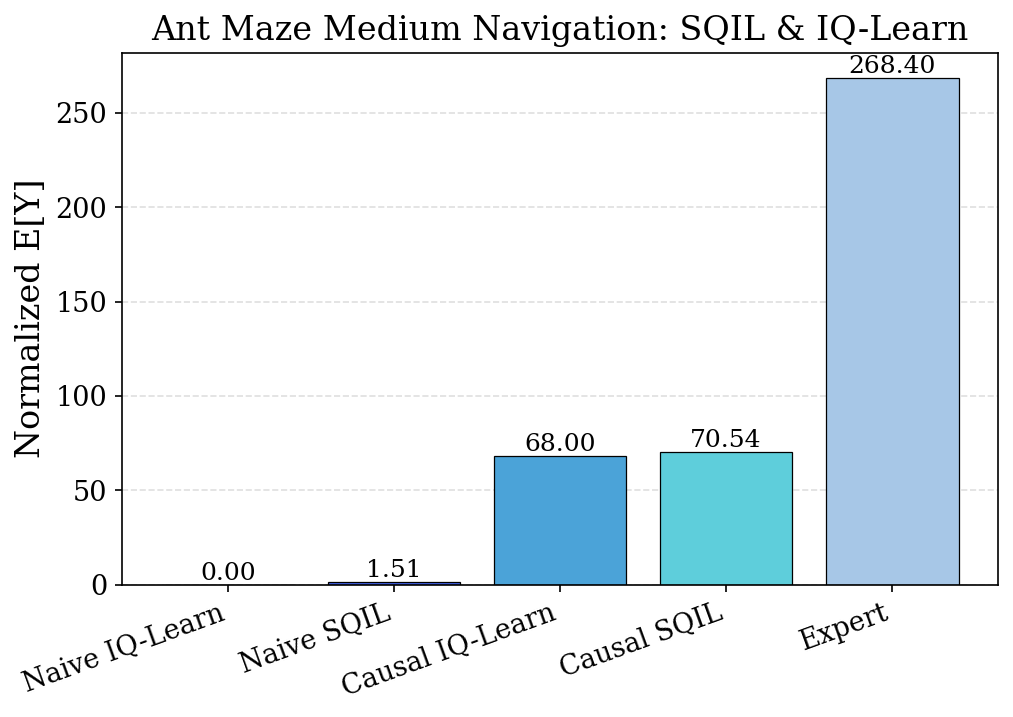

In [22]:
plt.rcParams.update({
    "font.family": "serif", "font.size": 14,
    "axes.titlesize": 16, "axes.labelsize": 16,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "figure.dpi": 150
})

labels = ['Expert', 'Causal SQIL', 'Naive SQIL', 'Causal IQ-Learn', 'Naive IQ-Learn']
reward_lists = [
    expert_rewards,
    all_rewards['Causal SQIL'], all_rewards['Naive SQIL'],
    all_rewards['Causal IQ-Learn'], all_rewards['Naive IQ-Learn']
]

averages = [np.mean(r) for r in reward_lists]
stds = [np.std(r) for r in reward_lists]

# Normalize
min_avg = min(averages)
averages_norm = [a - min_avg for a in averages]

# Sort
sorted_data = sorted(zip(averages_norm, stds, labels))
averages_norm, stds, labels = map(list, zip(*sorted_data))

colors = ['#0A5E8C', '#4263EB', '#4BA3D8', '#5ECEDB', '#A7C7E7']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, averages_norm, capsize=4, color=colors, edgecolor="black", linewidth=0.6)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.set_ylabel("Normalized E[Y]")
ax.set_title("Ant Maze Medium Navigation: SQIL & IQ-Learn")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
for bar, avg in zip(bars, averages_norm):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{avg:.2f}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('antmaze_sqil_iqlearn_eval.pdf', dpi=300)
plt.show()

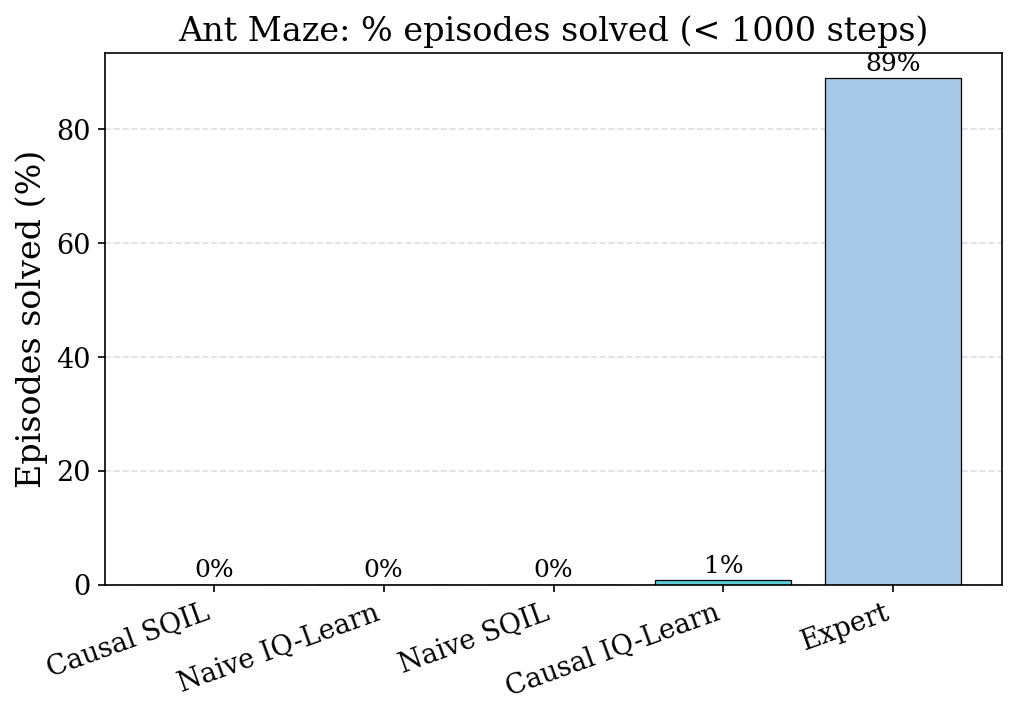

In [23]:
def compute_success_rate(traj_records, max_steps):
    ep_lengths = defaultdict(int)
    for rec in traj_records:
        ep_lengths[rec['episode']] += 1
    lengths = np.array(list(ep_lengths.values()))
    sr = (lengths < max_steps).mean()
    se = np.sqrt(sr * (1 - sr) / len(ep_lengths))
    return sr, se

labels_sr = ['Expert']
rates = [100 * compute_success_rate(records, num_steps)[0]]

for name in ['Causal SQIL', 'Naive SQIL', 'Causal IQ-Learn', 'Naive IQ-Learn']:
    sr, _ = compute_success_rate(all_records[name], num_steps)
    labels_sr.append(name)
    rates.append(100 * sr)

sorted_data = sorted(zip(rates, labels_sr))
rates, labels_sr = map(list, zip(*sorted_data))

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels_sr, rates, color=colors, edgecolor="black", linewidth=0.6)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.set_ylabel("Episodes solved (%)")
ax.set_title("Ant Maze: % episodes solved (< 1000 steps)")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate:.0f}%', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('antmaze_sqil_iqlearn_success_rate.pdf', dpi=300)
plt.show()

/tmp/ipykernel_3638542/2709032836.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_lengths, labels=labels_len, patch_artist=True,


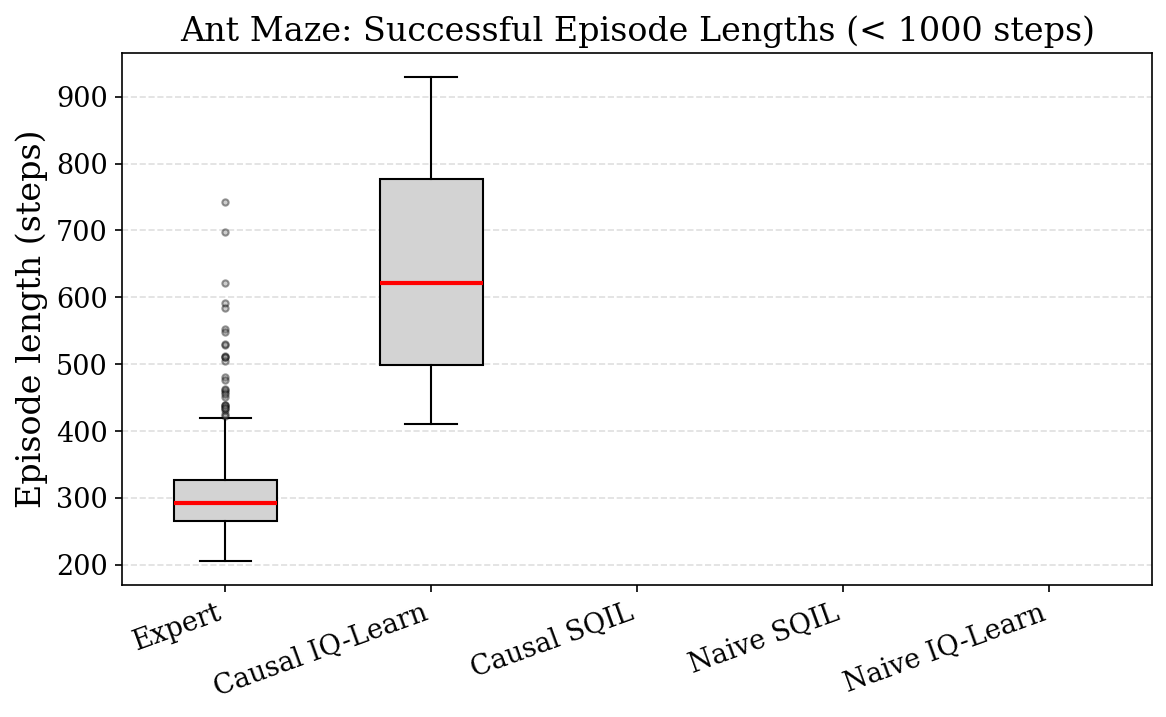

In [24]:
def get_success_lengths(traj_records, max_steps):
    ep_lengths = defaultdict(int)
    for rec in traj_records:
        ep_lengths[rec['episode']] += 1
    return [l for l in ep_lengths.values() if l < max_steps]

expert_len = get_success_lengths(records, num_steps)
all_lengths = [expert_len]
labels_len = ['Expert']

for name in ['Causal SQIL', 'Naive SQIL', 'Causal IQ-Learn', 'Naive IQ-Learn']:
    all_lengths.append(get_success_lengths(all_records[name], num_steps))
    labels_len.append(name)

sorted_pack = sorted(zip(all_lengths, labels_len), key=lambda x: np.mean(x[0]) if len(x[0]) > 0 else np.inf)
all_lengths, labels_len = map(list, zip(*sorted_pack))

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(all_lengths, labels=labels_len, patch_artist=True,
           boxprops=dict(facecolor='lightgray', edgecolor='black', linewidth=1.0),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='black'),
           capprops=dict(color='black'),
           flierprops=dict(marker='o', markersize=3, markerfacecolor='gray', alpha=0.4))
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.set_ylabel("Episode length (steps)")
ax.set_title("Ant Maze: Successful Episode Lengths (< 1000 steps)")
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig('antmaze_sqil_iqlearn_success_lengths.pdf', dpi=300)
plt.show()

/tmp/ipykernel_3638542/1393882124.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=labels_box, showmeans=True,


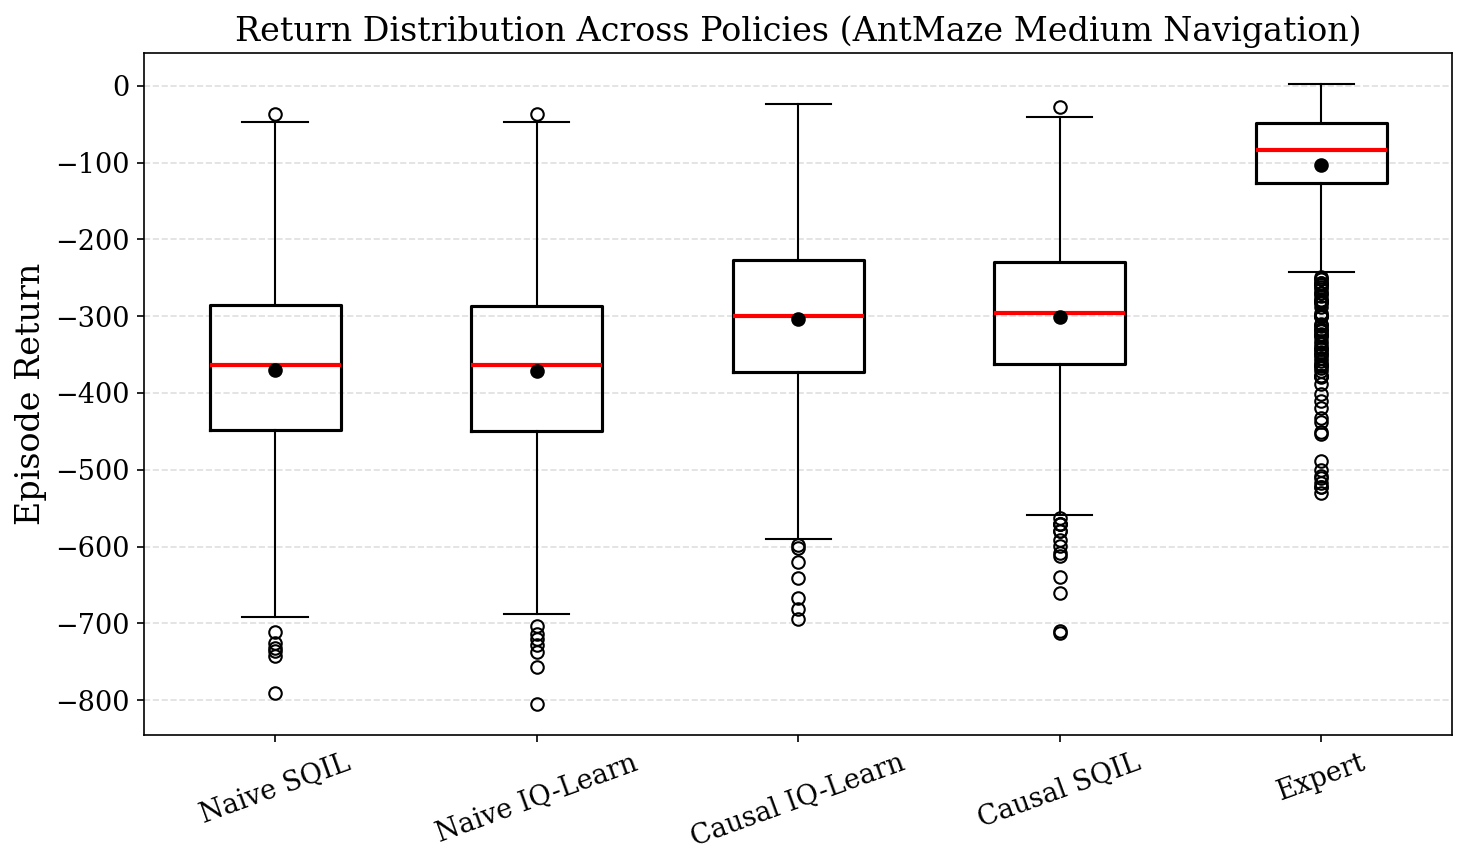

In [25]:
labels_box = [
    'Naive SQIL', 'Naive IQ-Learn',
    'Causal IQ-Learn', 'Causal SQIL', 'Expert'
]
data_box = [
    all_rewards['Naive SQIL'], all_rewards['Naive IQ-Learn'],
    all_rewards['Causal IQ-Learn'], all_rewards['Causal SQIL'],
    expert_rewards,
]

plt.figure(figsize=(10, 6))
plt.boxplot(data_box, labels=labels_box, showmeans=True,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
            boxprops=dict(linewidth=1.5),
            medianprops=dict(linewidth=2, color="red"))
plt.ylabel("Episode Return")
plt.title("Return Distribution Across Policies (AntMaze Medium Navigation)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig('antmaze_sqil_iqlearn_return_distribution.pdf', dpi=300)
plt.show()

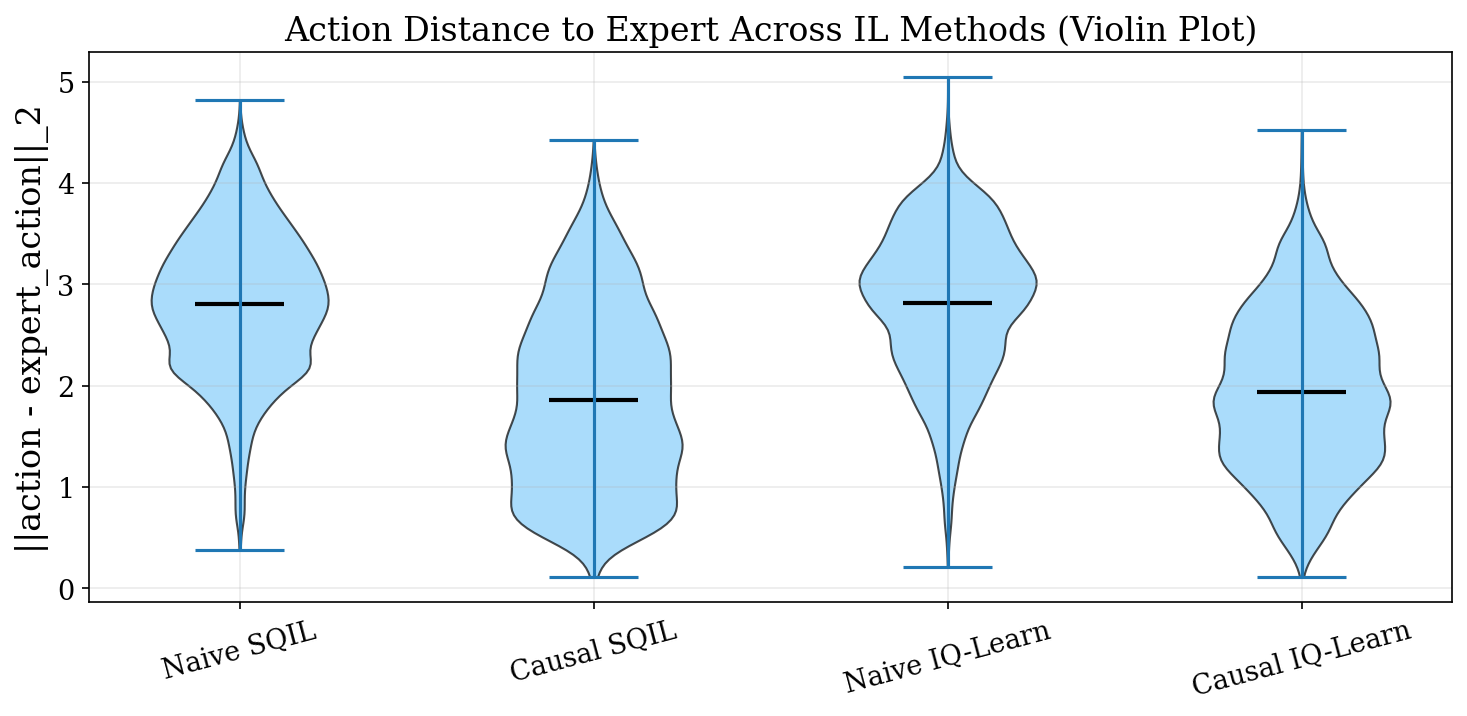

In [26]:
N_SAMPLES = 10000
np.random.seed(0)
idxs = np.random.choice(len(records), size=min(N_SAMPLES, len(records)), replace=False)
records_sampled = [records[i] for i in idxs]

def action_distance(policy_fn, recs):
    diffs = []
    for rec in recs:
        obs = rec["obs"]
        a_exp = rec["action"].astype(np.float32)
        a_pi  = policy_fn(obs).astype(np.float32)
        diffs.append(np.linalg.norm(a_pi - a_exp))
    return np.array(diffs)

d_causal_sqil  = action_distance(causal_sqil_policy, records_sampled)
d_naive_sqil   = action_distance(naive_sqil_policy, records_sampled)
d_causal_iq    = action_distance(causal_iq_policy, records_sampled)
d_naive_iq     = action_distance(naive_iq_policy, records_sampled)

data = [d_naive_sqil, d_causal_sqil, d_naive_iq, d_causal_iq]
labels_v = ["Naive SQIL", "Causal SQIL", "Naive IQ-Learn", "Causal IQ-Learn"]

plt.figure(figsize=(10, 5))
parts = plt.violinplot(data, showmeans=True, showextrema=True, showmedians=False)
for pc in parts['bodies']:
    pc.set_facecolor("#87CEFA")
    pc.set_edgecolor("black")
    pc.set_alpha(0.7)
parts['cmeans'].set_edgecolor("black")
parts['cmeans'].set_linewidth(2)
plt.xticks(np.arange(1, len(labels_v)+1), labels_v, rotation=15)
plt.ylabel("||action - expert_action||_2")
plt.title("Action Distance to Expert Across IL Methods (Violin Plot)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('antmaze_sqil_iqlearn_action_distance_violin.pdf', dpi=300)
plt.show()

In [27]:
all_data = {
    'Expert': expert_rewards,
    'Causal SQIL': all_rewards['Causal SQIL'],
    'Naive SQIL': all_rewards['Naive SQIL'],
    'Causal IQ-Learn': all_rewards['Causal IQ-Learn'],
    'Naive IQ-Learn': all_rewards['Naive IQ-Learn'],
}

for label, arr in all_data.items():
    arr = list(arr)
    print(f"{label:18s} | mean = {np.mean(arr):8.2f} | std = {np.std(arr):6.2f} | min = {np.min(arr):8.2f} | max = {np.max(arr):8.2f}")

Expert             | mean =  -103.55 | std =  87.30 | min =  -530.55 | max =     2.00
Causal SQIL        | mean =  -301.41 | std = 101.69 | min =  -712.59 | max =   -28.27
Naive SQIL         | mean =  -370.44 | std = 118.85 | min =  -790.87 | max =   -36.24
Causal IQ-Learn    | mean =  -303.95 | std = 106.34 | min =  -693.86 | max =   -23.28
Naive IQ-Learn     | mean =  -371.95 | std = 119.52 | min =  -804.81 | max =   -36.96


# Trajectory Visualization

In [28]:
from matplotlib.collections import LineCollection

def get_episode_xy_from_records(records, episode_id: int):
    ep = [r for r in records if r['episode'] == episode_id]
    ep = sorted(ep, key=lambda r: r['step'])
    xs, ys = [], []
    for r in ep:
        pos = r['obs']['P'][-1]
        xs.append(pos[0])
        ys.append(pos[1])
    return np.array(xs), np.array(ys)

def plot_ant_trajectory_xy(records, episode_id: int = 0, ax=None, title_prefix='AntMaze'):
    xs, ys = get_episode_xy_from_records(records, episode_id)
    T = len(xs)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure
    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    t_norm = np.linspace(0, 1, T-1)
    lc = LineCollection(segments, cmap='viridis', norm=plt.Normalize(0, 1))
    lc.set_array(t_norm)
    lc.set_linewidth(2.5)
    ax.add_collection(lc)
    ax.scatter(xs[0], ys[0], s=80, c='green', marker='o', edgecolors='black', label='Start')
    ax.scatter(xs[-1], ys[-1], s=80, c='red', marker='X', edgecolors='black', label='End')
    step = max(1, T // 30)
    for i in range(0, T-1, step):
        dx = xs[i+1] - xs[i]
        dy = ys[i+1] - ys[i]
        ax.arrow(xs[i], ys[i], dx, dy, length_includes_head=True,
                 head_width=0.2, head_length=0.4, alpha=0.6)
    cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Time (normalized)')
    ax.set_aspect('equal', 'box')
    ax.set_xlabel('x position')
    ax.set_ylabel('y position')
    ax.set_title(f'{title_prefix} - Episode {episode_id} trajectory')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper left')
    plt.tight_layout()
    return fig, ax

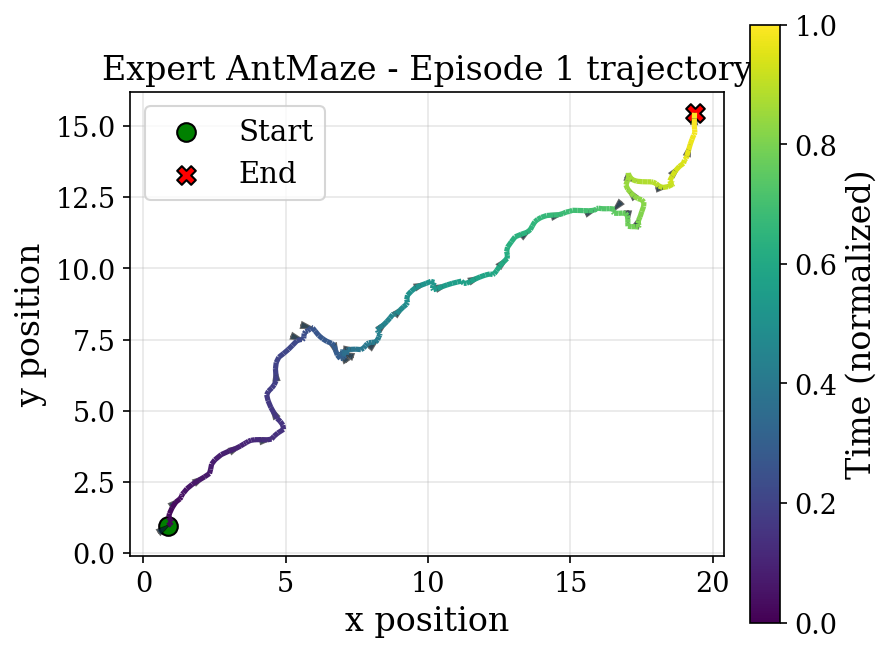

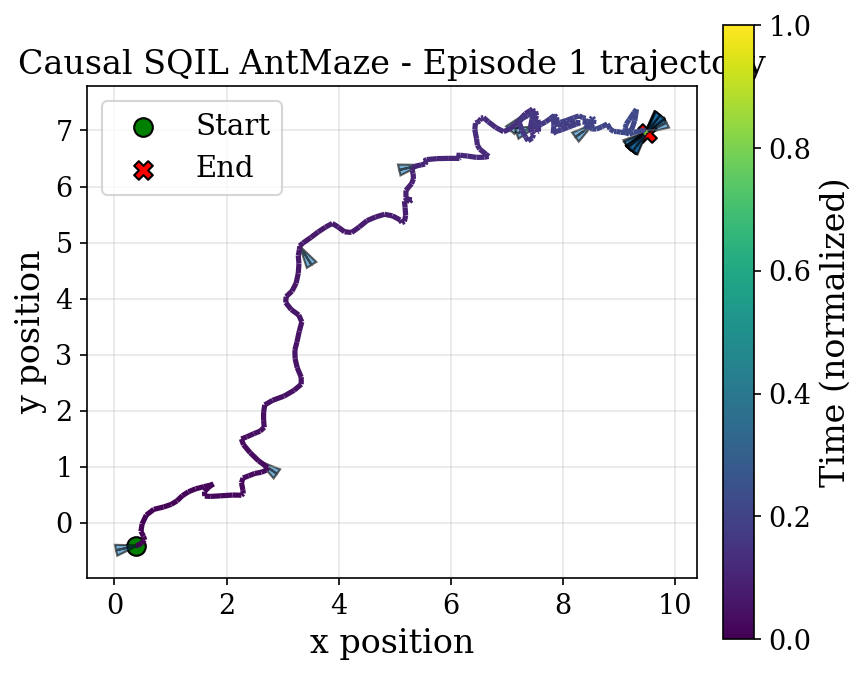

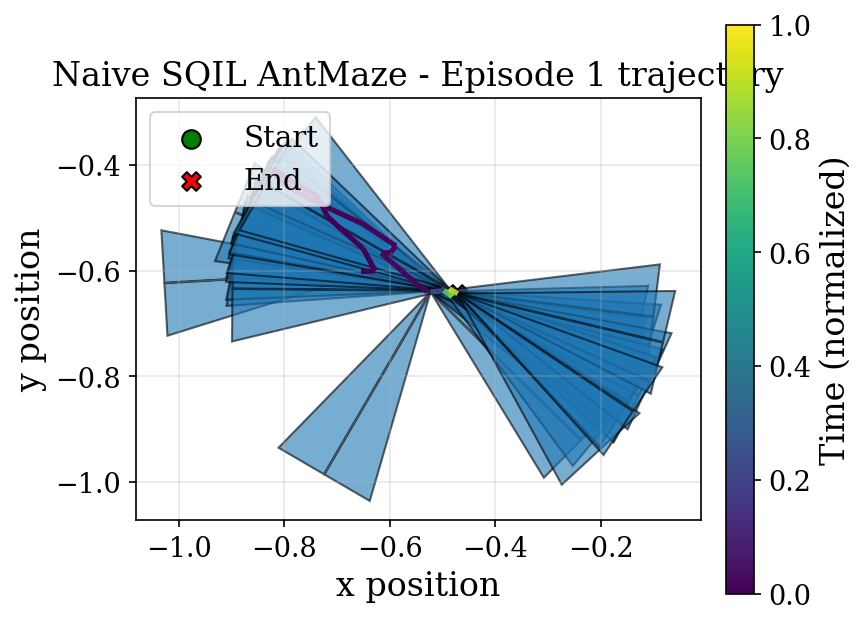

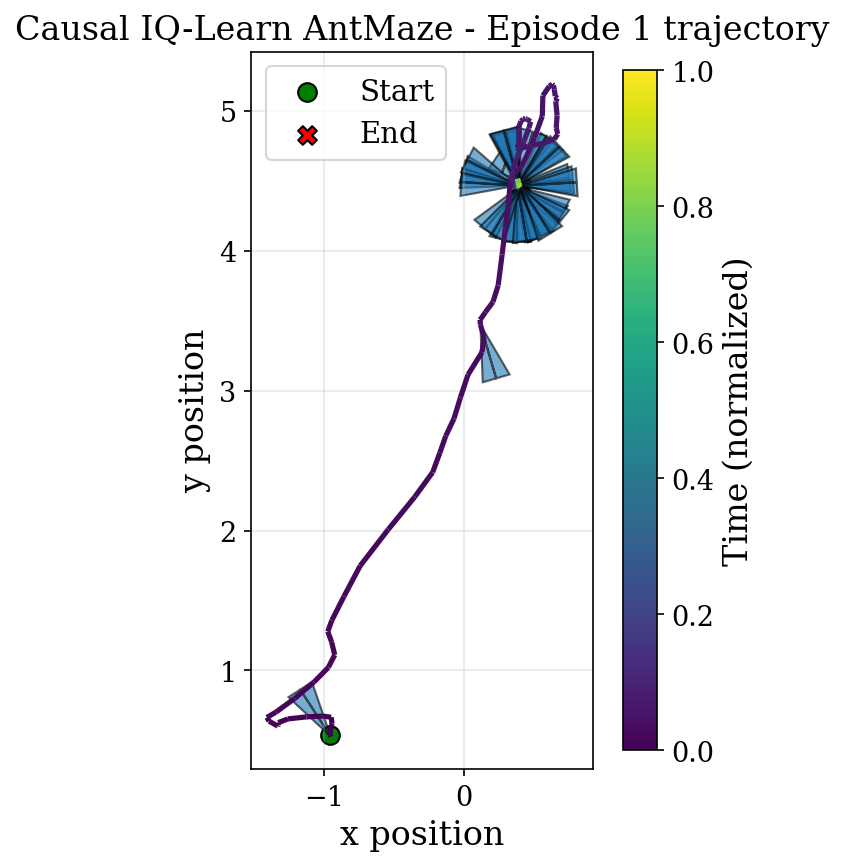

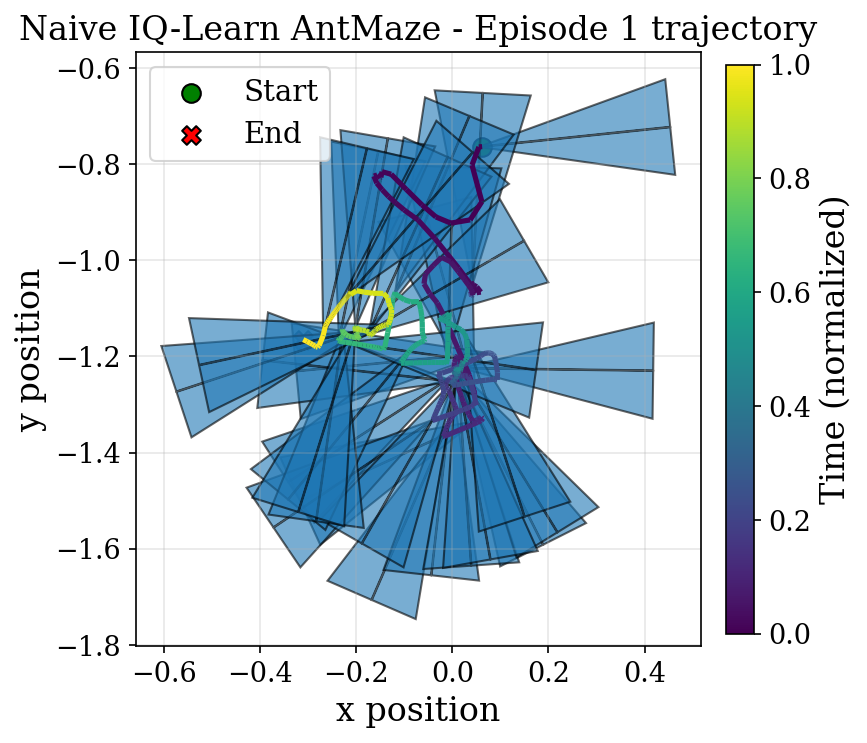

In [29]:
ep_id = 1

fig, ax = plot_ant_trajectory_xy(records, episode_id=ep_id, title_prefix='Expert AntMaze')
plt.show()

for name, recs in [('Causal SQIL', all_records['Causal SQIL']),
                   ('Naive SQIL', all_records['Naive SQIL']),
                   ('Causal IQ-Learn', all_records['Causal IQ-Learn']),
                   ('Naive IQ-Learn', all_records['Naive IQ-Learn'])]:
    fig, ax = plot_ant_trajectory_xy(recs, episode_id=ep_id, title_prefix=f'{name} AntMaze')
    plt.show()

# Learning Curves

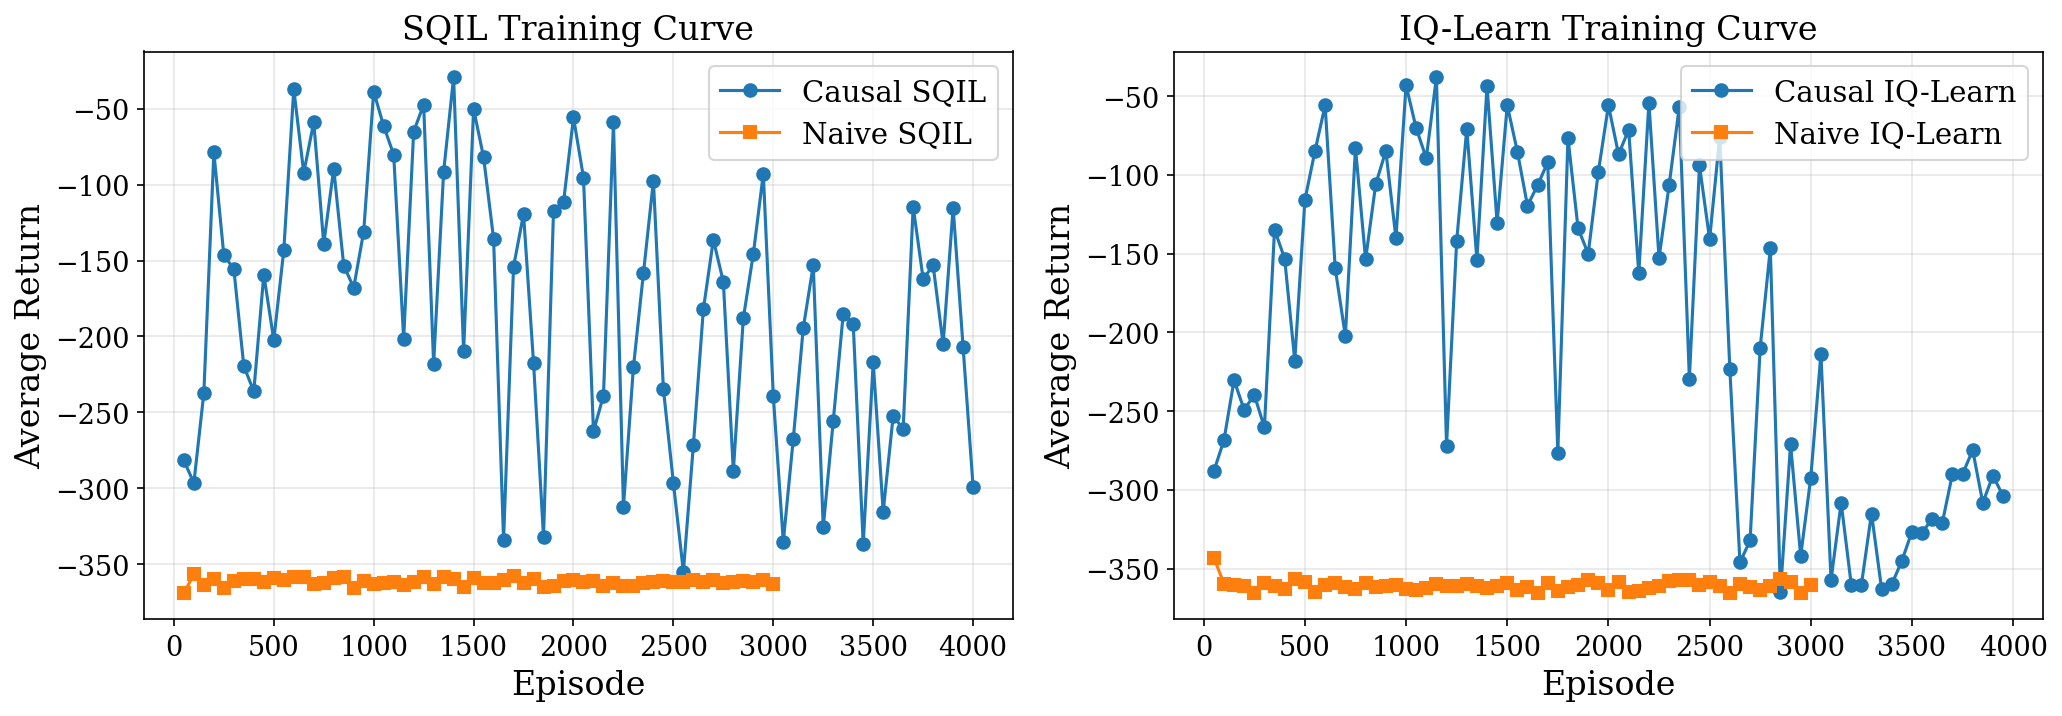

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if logs_causal_sqil:
    ax1.plot([l['episode'] for l in logs_causal_sqil],
             [l['eval_return'] for l in logs_causal_sqil], marker='o', label='Causal SQIL')
if logs_naive_sqil:
    ax1.plot([l['episode'] for l in logs_naive_sqil],
             [l['eval_return'] for l in logs_naive_sqil], marker='s', label='Naive SQIL')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Average Return')
ax1.set_title('SQIL Training Curve')
ax1.legend()
ax1.grid(alpha=0.3)

if logs_causal_iq:
    ax2.plot([l['episode'] for l in logs_causal_iq],
             [l['eval_return'] for l in logs_causal_iq], marker='o', label='Causal IQ-Learn')
if logs_naive_iq:
    ax2.plot([l['episode'] for l in logs_naive_iq],
             [l['eval_return'] for l in logs_naive_iq], marker='s', label='Naive IQ-Learn')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Average Return')
ax2.set_title('IQ-Learn Training Curve')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('antmaze_sqil_iqlearn_learning_curves.pdf', dpi=300)
plt.show()

# Save Models

In [31]:
SAVE_DIR = '/home/et2842/causal/causalrl/models'
os.makedirs(SAVE_DIR, exist_ok=True)

for name, actor, z_dim, Z_trim_used in [
    ('antmaze_causal_sqil', causal_sqil_actor, causal_z_dim, causal_Z_trim),
    ('antmaze_naive_sqil', naive_sqil_actor, naive_z_dim, naive_Z_trim),
    ('antmaze_causal_iqlearn', causal_iq_actor, causal_z_dim, causal_Z_trim),
    ('antmaze_naive_iqlearn', naive_iq_actor, naive_z_dim, naive_Z_trim),
]:
    ckpt = {
        'state_dict': actor.state_dict(),
        'z_dim': z_dim,
        'action_dim': action_dim,
        'hidden_size_actor': hidden_dim,
        'num_blocks_actor': num_blocks_actor,
        'dropout_actor': dropout_actor,
        'layernorm_actor': layernorm_actor,
        'final_tanh': True,
        'action_bounds_low': env.env.action_space.low,
        'action_bounds_high': env.env.action_space.high,
        'Z_sets': Z_trim_used,
        'dims': dims,
        'lookback': lookback,
    }
    path = os.path.join(SAVE_DIR, f'{name}.pt')
    torch.save(ckpt, path)
    print(f'Saved {name} to: {path}')

Saved antmaze_causal_sqil to: /home/et2842/causal/causalrl/models/antmaze_causal_sqil.pt
Saved antmaze_naive_sqil to: /home/et2842/causal/causalrl/models/antmaze_naive_sqil.pt
Saved antmaze_causal_iqlearn to: /home/et2842/causal/causalrl/models/antmaze_causal_iqlearn.pt
Saved antmaze_naive_iqlearn to: /home/et2842/causal/causalrl/models/antmaze_naive_iqlearn.pt
